In [25]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from langgraph.graph import START,END
from langgraph.graph.state import StateGraph 
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from langgraph.prebuilt import ToolNode , tools_condition
from typing import Annotated
from IPython.display import Image
load_dotenv()


True

In [26]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"


In [27]:
llm = ChatGroq(
    model = "qwen/qwen3.8-27b",
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x000001577F0B2710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001577F0B3110>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [28]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]
    
@tool
def add(a : int, b:int):
    """add two numbers"""
    return a+b

tools = [add]
tool_node = ToolNode(tools)

llm_with_tools = llm.bind_tools(tools)

def call_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


In [ ]:
config = {"thread_id": "1"}

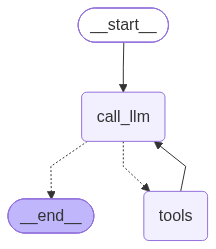

In [33]:
##graph creating
graph_builder = StateGraph(State)

##adding nodes
graph_builder.add_node("call_llm",call_llm)
graph_builder.add_node("tools",ToolNode(tools))

##adding edges
graph_builder.add_edge(START,"call_llm")
graph_builder.add_conditional_edges("call_llm",tools_condition)
graph_builder.add_edge("tools","call_llm")

memory = InMemorySaver()
graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
res = graph.invoke({"messages" : "what is 24 + 34"})
res

{'messages': [HumanMessage(content='what is 24 + 34', additional_kwargs={}, response_metadata={}, id='50ce60fe-52f5-4f76-b19e-ce6c5564e90e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dvfz6v7a2', 'function': {'arguments': '{"a":24,"b":34}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 287, 'total_tokens': 324, 'completion_time': 0.077247492, 'completion_tokens_details': None, 'prompt_time': 0.024906825, 'prompt_tokens_details': None, 'queue_time': 0.069874675, 'total_time': 0.102154317}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_4560dae850', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ae16-03d8-7cb1-86c7-dec863fdcac5-0', tool_calls=[{'name': 'add', 'args': {'a': 24, 'b': 34}, 'id': 'dvfz6v7a2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 287, 'output_tokens': 37, 't